# Notebook 04 - SINDy Library Construction
**SINDy with Environmental Covariates on DengAI Data**

---
### Objectives
1. Build Sub-Library A: dynamical/state terms (SIR interactions)
2. Build Sub-Library B: environmental modulation terms (T, P, H, V and their nonlinear/lagged combinations)
3. Construct full cross-interaction library Theta_full = Theta_dyn x Theta_env
4. Validate library: check for NaN/Inf, inspect condition number, visualise key terms
5. Save library matrices and feature names for use in Notebook 05
---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from src.plot_utils import set_project_style, PALETTE, city_label, city_color, save_fig

set_project_style()
print('All imports ready')

All imports ready


## 1 . Load Dynamics Data

In [2]:
df_sj = pd.read_csv('../data_processed/sj_dynamics.csv', parse_dates=['week_start_date'])
df_iq = pd.read_csv('../data_processed/iq_dynamics.csv', parse_dates=['week_start_date'])

print(f'San Juan : {len(df_sj)} rows')
print(f'Iquitos  : {len(df_iq)} rows')
print(f'Columns  : {list(df_sj.columns)}')

San Juan : 933 rows
Iquitos  : 517 rows
Columns  : ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases', 'T', 'P', 'H', 'V', 'T_lag1', 'P_lag1', 'P_lag2', 'P_lag3', 'sin_season', 'cos_season', 'i_h', 'r_h', 's_h', 's_h_smooth', 'i_h_smooth', 'r_h_smooth', 'ds_h_dt', 'di_h_dt', 'dr_h_dt']


## 2 . Sub-Library A: Dynamical (State) Terms

Per blueprint Sub-Library A:
```
Theta_dyn = [1, s_h, i_h, r_h, s_h*i_h, s_h^2, i_h^2, s_h*i_h/(1+a*i_h)]
```
The key SIR interaction term `s_h * i_h` is the standard mass-action transmission.

In [3]:
def build_dyn_library(df, alpha=10.0):
    """
    Build the dynamical sub-library from smoothed SIR states.
    alpha: saturation parameter for the Holling type-II incidence term.
    """
    s = df['s_h_smooth'].values
    i = df['i_h_smooth'].values
    r = df['r_h_smooth'].values

    lib = {
        'const'          : np.ones(len(df)),
        's_h'            : s,
        'i_h'            : i,
        'r_h'            : r,
        's_h*i_h'        : s * i,
        's_h^2'          : s ** 2,
        'i_h^2'          : i ** 2,
        'si_sat'         : s * i / (1.0 + alpha * i),   # saturating incidence
    }
    return pd.DataFrame(lib)


Theta_dyn_sj = build_dyn_library(df_sj)
Theta_dyn_iq = build_dyn_library(df_iq)

print('Dynamical library shape (SJ):', Theta_dyn_sj.shape)
print('Features:', list(Theta_dyn_sj.columns))
Theta_dyn_sj.describe().round(6)

Dynamical library shape (SJ): (933, 8)
Features: ['const', 's_h', 'i_h', 'r_h', 's_h*i_h', 's_h^2', 'i_h^2', 'si_sat']


,const,s_h,i_h,r_h,s_h*i_h,s_h^2,i_h^2,si_sat
count,933.0,933.000000,933.000000,933.000000,933.000000,933.000000,933.000000,933.000000
mean,1.0,0.898363,0.000086,0.101551,0.000077,0.807057,0.000000,0.000077
std,0.0,0.000775,0.000127,0.000790,0.000114,0.001393,0.000000,0.000113
min,1.0,0.897080,0.000001,0.100000,0.000001,0.804753,0.000000,0.000001
25%,1.0,0.897742,0.000024,0.101008,0.000022,0.805940,0.000000,0.000022
50%,1.0,0.898037,0.000046,0.101864,0.000042,0.806470,0.000000,0.000042
75%,1.0,0.898792,0.000092,0.102203,0.000082,0.807828,0.000000,0.000082
max,1.0,0.899992,0.001026,0.102638,0.000922,0.809986,0.000001,0.000912


## 3 . Sub-Library B: Environmental Modulation Terms

Per blueprint:
```
Theta_env = [T, P, H, V, T^2, P^2, T*P, T*H, T*V, P*H, P*V, H*V,
             T*P*H, T*P*V, T(t-1), P(t-2), P(t-3), sin, cos]
```

In [4]:
def build_env_library(df):
    """
    Build the environmental sub-library from aggregated covariates.
    Includes linear, quadratic, pairwise cross, triple cross, lagged, seasonal terms.
    """
    T = df['T'].values
    P = df['P'].values
    H = df['H'].values
    V = df['V'].values
    Tl = df['T_lag1'].values
    Pl1 = df['P_lag1'].values
    Pl2 = df['P_lag2'].values
    Pl3 = df['P_lag3'].values
    sin_s = df['sin_season'].values
    cos_s = df['cos_season'].values

    lib = {
        # Linear
        'T'       : T,
        'P'       : P,
        'H'       : H,
        'V'       : V,
        # Quadratic
        'T^2'     : T ** 2,
        'P^2'     : P ** 2,
        'H^2'     : H ** 2,
        'V^2'     : V ** 2,
        # Pairwise cross-products
        'T*P'     : T * P,
        'T*H'     : T * H,
        'T*V'     : T * V,
        'P*H'     : P * H,
        'P*V'     : P * V,
        'H*V'     : H * V,
        # Triple cross-products (key mechanistic terms)
        'T*P*H'   : T * P * H,
        'T*P*V'   : T * P * V,
        'T*H*V'   : T * H * V,
        'P*H*V'   : P * H * V,
        # Lagged terms (ecological delay)
        'T_lag1'  : Tl,
        'P_lag1'  : Pl1,
        'P_lag2'  : Pl2,
        'P_lag3'  : Pl3,
        # Lagged cross-products
        'T*P_lag2': T * Pl2,
        'T*P_lag3': T * Pl3,
        # Seasonal basis
        'sin'     : sin_s,
        'cos'     : cos_s,
    }
    return pd.DataFrame(lib)


Theta_env_sj = build_env_library(df_sj)
Theta_env_iq = build_env_library(df_iq)

print('Environmental library shape (SJ):', Theta_env_sj.shape)
print('Features:', list(Theta_env_sj.columns))

Environmental library shape (SJ): (933, 26)
Features: ['T', 'P', 'H', 'V', 'T^2', 'P^2', 'H^2', 'V^2', 'T*P', 'T*H', 'T*V', 'P*H', 'P*V', 'H*V', 'T*P*H', 'T*P*V', 'T*H*V', 'P*H*V', 'T_lag1', 'P_lag1', 'P_lag2', 'P_lag3', 'T*P_lag2', 'T*P_lag3', 'sin', 'cos']


## 4 . Full Augmented Library: Theta_dyn x Theta_env

The key novelty of the blueprint: cross-product of dynamical and environmental terms.
This lets SINDy discover terms like `s_h * i_h * T(t)` — transmission scaling with temperature.

> **Note:** We only cross the *most mechanistically meaningful* dynamical term (`s_h*i_h`) with all environmental terms to keep the library tractable and avoid overfitting.

In [5]:
def build_full_library(df_dyn, df_env):
    """
    Cross-product library: keeps all pure dynamical and pure environmental terms,
    then adds s_h*i_h * each_env term as the key interaction column.
    Per blueprint: Theta_full = Theta_dyn TENSOR Theta_env
    """
    # Start with all dynamical terms
    frames = [df_dyn.copy()]

    # Add all environmental terms
    frames.append(df_env.copy())

    # Add s_h*i_h crossed with every environmental term
    si = df_dyn['s_h*i_h'].values
    cross_terms = {}
    for col in df_env.columns:
        cross_terms[f'si*{col}'] = si * df_env[col].values
    frames.append(pd.DataFrame(cross_terms))

    # Also cross i_h alone with temperature (direct forcing)
    i_h = df_dyn['i_h'].values
    extra = {
        'i_h*T'     : i_h * df_env['T'].values,
        'i_h*P_lag2': i_h * df_env['P_lag2'].values,
        'i_h*H'     : i_h * df_env['H'].values,
    }
    frames.append(pd.DataFrame(extra))

    return pd.concat(frames, axis=1)


Theta_sj = build_full_library(Theta_dyn_sj, Theta_env_sj)
Theta_iq = build_full_library(Theta_dyn_iq, Theta_env_iq)

print(f'Full library shape - SJ: {Theta_sj.shape}  |  IQ: {Theta_iq.shape}')
print(f'Total candidate terms: {Theta_sj.shape[1]}')
print(f'\nAll feature names:\n{list(Theta_sj.columns)}')

Full library shape - SJ: (933, 63)  |  IQ: (517, 63)
Total candidate terms: 63

All feature names:
['const', 's_h', 'i_h', 'r_h', 's_h*i_h', 's_h^2', 'i_h^2', 'si_sat', 'T', 'P', 'H', 'V', 'T^2', 'P^2', 'H^2', 'V^2', 'T*P', 'T*H', 'T*V', 'P*H', 'P*V', 'H*V', 'T*P*H', 'T*P*V', 'T*H*V', 'P*H*V', 'T_lag1', 'P_lag1', 'P_lag2', 'P_lag3', 'T*P_lag2', 'T*P_lag3', 'sin', 'cos', 'si*T', 'si*P', 'si*H', 'si*V', 'si*T^2', 'si*P^2', 'si*H^2', 'si*V^2', 'si*T*P', 'si*T*H', 'si*T*V', 'si*P*H', 'si*P*V', 'si*H*V', 'si*T*P*H', 'si*T*P*V', 'si*T*H*V', 'si*P*H*V', 'si*T_lag1', 'si*P_lag1', 'si*P_lag2', 'si*P_lag3', 'si*T*P_lag2', 'si*T*P_lag3', 'si*sin', 'si*cos', 'i_h*T', 'i_h*P_lag2', 'i_h*H']


## 5 . Library Validation

In [6]:
# 5a: Check for NaN / Inf
nan_counts = Theta_sj.isnull().sum()
inf_counts = np.isinf(Theta_sj.values).sum(axis=0)

print('=== San Juan Library - NaN / Inf check ===')
print(f'Total NaNs : {nan_counts.sum()}')
print(f'Total Infs : {inf_counts.sum()}')

if nan_counts.sum() > 0:
    print('Columns with NaN:', list(nan_counts[nan_counts > 0].index))
if inf_counts.sum() > 0:
    print('Columns with Inf:', list(Theta_sj.columns[inf_counts > 0]))
else:
    print('Library is clean - no NaN or Inf values')

=== San Juan Library - NaN / Inf check ===
Total NaNs : 0
Total Infs : 0
Library is clean - no NaN or Inf values


In [7]:
# 5b: Column norms - detect degenerate (near-zero) columns
norms = np.linalg.norm(Theta_sj.values, axis=0)
norm_df = pd.DataFrame({'feature': Theta_sj.columns, 'L2_norm': norms})
norm_df = norm_df.sort_values('L2_norm')

print('5 smallest norms (potential near-zero columns):')
print(norm_df.head())
print(f'\n5 largest norms:')
print(norm_df.tail())

5 smallest norms (potential near-zero columns):
   feature   L2_norm
6    i_h^2  0.000003
41  si*V^2  0.000144
37    si*V  0.000684
58  si*sin  0.002782
59  si*cos  0.003138

5 largest norms:
   feature       L2_norm
17     T*H  6.397423e+04
19     P*H  1.133185e+05
13     P^2  1.773969e+05
14     H^2  1.896113e+05
22   T*P*H  3.024633e+06


In [8]:
# 5c: Condition number of the library matrix
# A very large condition number (> 1e10) would indicate severe multicollinearity
cond_num = np.linalg.cond(Theta_sj.values)
print(f'Condition number of Theta_sj: {cond_num:.3e}')
if cond_num > 1e10:
    print('WARNING: High condition number - consider normalising columns or using PCA')
else:
    print('Condition number is acceptable')

Condition number of Theta_sj: 7.491e+17


## 6 . Column Normalisation

Normalise each library column to unit variance so that STLSQ thresholding
is applied uniformly regardless of scale differences between T (~27), P (~30), V (~0.2), etc.

In [9]:
from sklearn.preprocessing import StandardScaler

def normalise_library(Theta):
    scaler = StandardScaler()
    Theta_norm = pd.DataFrame(
        scaler.fit_transform(Theta),
        columns=Theta.columns
    )
    return Theta_norm, scaler


Theta_sj_norm, scaler_sj = normalise_library(Theta_sj)
Theta_iq_norm, scaler_iq = normalise_library(Theta_iq)

print('Normalised library - SJ sample stats:')
print(Theta_sj_norm.describe().loc[['mean', 'std']].round(4))

Normalised library - SJ sample stats:
      const     s_h     i_h     r_h  s_h*i_h   s_h^2   i_h^2  si_sat       T  \
mean    0.0  0.0000  0.0000 -0.0000  -0.0000 -0.0000  0.0000  0.0000  0.0000   
std     0.0  1.0005  1.0005  1.0005   1.0005  1.0005  1.0005  1.0005  1.0005   

           P  ...  si*P_lag1  si*P_lag2  si*P_lag3  si*T*P_lag2  si*T*P_lag3  \
mean  0.0000  ...     0.0000    -0.0000     0.0000       0.0000       0.0000   
std   1.0005  ...     1.0005     1.0005     1.0005       1.0005       1.0005   

      si*sin  si*cos   i_h*T  i_h*P_lag2   i_h*H  
mean  0.0000  0.0000  0.0000      0.0000 -0.0000  
std   1.0005  1.0005  1.0005      1.0005  1.0005  

[2 rows x 63 columns]


## 7 . Visualise Key Library Terms

  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\04_key_terms_vs_target.png


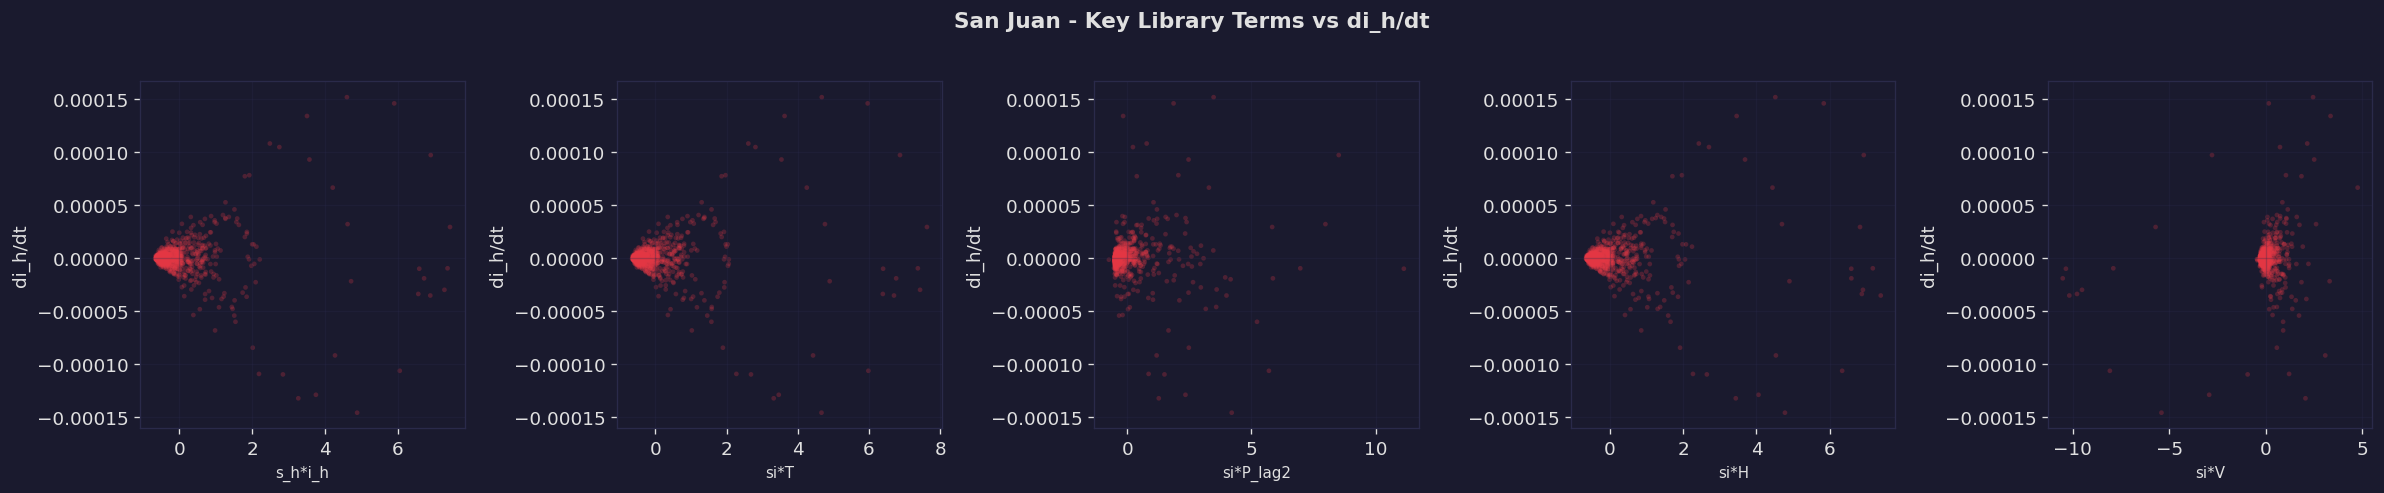

In [10]:
# Plot top mechanistically important cross-interaction terms vs di_h_dt
target = df_sj['di_h_dt'].values
key_terms = ['s_h*i_h', 'si*T', 'si*P_lag2', 'si*H', 'si*V']

fig, axes = plt.subplots(1, len(key_terms), figsize=(20, 4))
for ax, term in zip(axes, key_terms):
    ax.scatter(Theta_sj_norm[term], target, alpha=0.25, s=8,
               color=PALETTE['sj'], edgecolors='none')
    ax.set_xlabel(term, fontsize=9)
    ax.set_ylabel('di_h/dt')
    ax.grid(True, alpha=0.3)

fig.suptitle('San Juan - Key Library Terms vs di_h/dt', fontsize=13, y=1.02)
plt.tight_layout()
save_fig(fig, '04_key_terms_vs_target')
plt.show()

  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\04_term_correlations.png


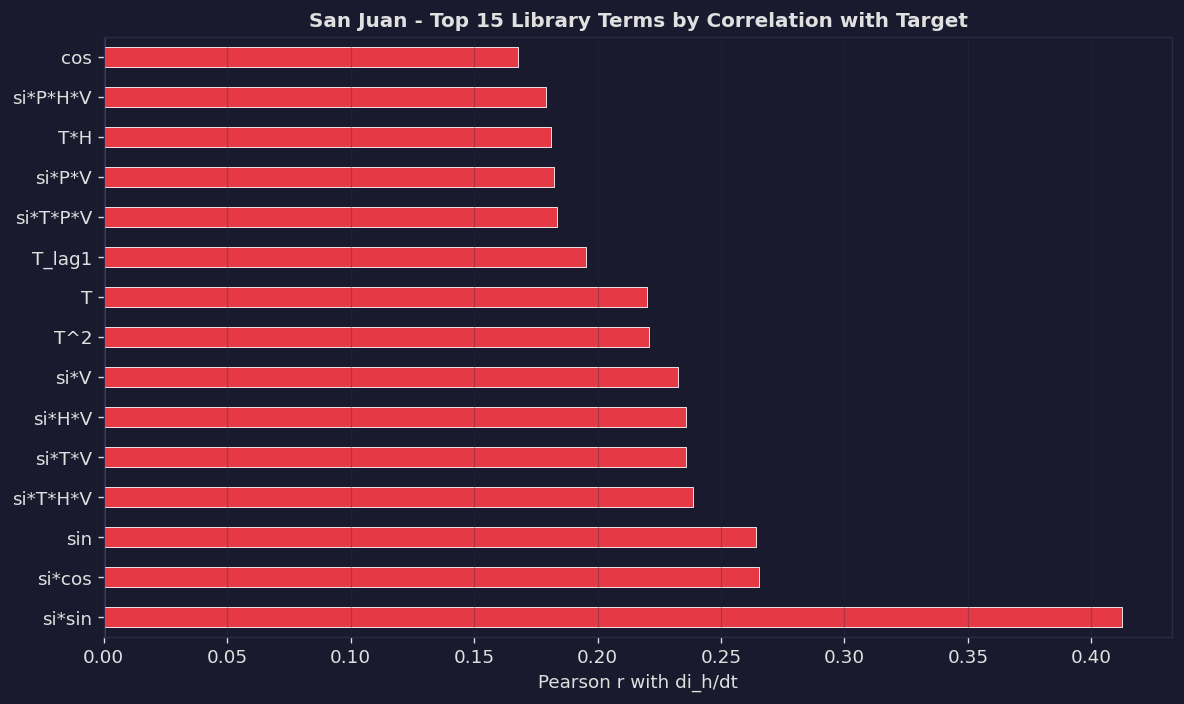

In [11]:
# Correlation heatmap of top 15 terms with target
target_series = pd.Series(df_sj['di_h_dt'].values, name='di_h_dt')
combined = pd.concat([Theta_sj_norm, target_series], axis=1)
corr_with_target = combined.corr()['di_h_dt'].drop('di_h_dt')
top15 = corr_with_target.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE['sj'] if v > 0 else PALETTE['iq'] for v in top15.values]
top15.plot.barh(ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_xlabel('Pearson r with di_h/dt')
ax.set_title('San Juan - Top 15 Library Terms by Correlation with Target', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, '04_term_correlations')
plt.show()

## 8 . Save Libraries

In [12]:
import os, pickle
os.makedirs('../data_processed', exist_ok=True)

# Save raw (un-normalised) libraries as CSV
Theta_sj.to_csv('../data_processed/library_sj.csv', index=False)
Theta_iq.to_csv('../data_processed/library_iq.csv', index=False)

# Save normalised versions
Theta_sj_norm.to_csv('../data_processed/library_sj_norm.csv', index=False)
Theta_iq_norm.to_csv('../data_processed/library_iq_norm.csv', index=False)

# Save targets (derivatives)
targets_sj = df_sj[['ds_h_dt', 'di_h_dt', 'dr_h_dt']].copy()
targets_iq = df_iq[['ds_h_dt', 'di_h_dt', 'dr_h_dt']].copy()
targets_sj.to_csv('../data_processed/targets_sj.csv', index=False)
targets_iq.to_csv('../data_processed/targets_iq.csv', index=False)

print(f'Library SJ    : {Theta_sj.shape[0]} rows x {Theta_sj.shape[1]} features')
print(f'Library IQ    : {Theta_iq.shape[0]} rows x {Theta_iq.shape[1]} features')
print(f'Targets SJ    : {targets_sj.shape}')
print('All files saved to data_processed/')

Library SJ    : 933 rows x 63 features
Library IQ    : 517 rows x 63 features
Targets SJ    : (933, 3)
All files saved to data_processed/


## Summary

| Sub-Library | Terms | Description |
|---|---|---|
| **Theta_dyn** | 8 | State terms: 1, s, i, r, si, s2, i2, saturating-si |
| **Theta_env** | 26 | Environmental: linear, quadratic, cross, lagged, seasonal |
| **si x env** | 26 | Key cross-interactions: s_h*i_h modulated by each env term |
| **i_h x env** | 3 | Extra direct forcing terms |
| **Total** | **63** | Full candidate library passed to STLSQ |

**Next -> Notebook 05: SINDy Discovery (STLSQ threshold sweep)**